In [1]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [5]:
# ----------------------------------------
# 2. Upload Files (User Upload Option)
# ----------------------------------------

print("Upload zoo-data.csv and zoo-class-type.csv")

try:
    # For Google Colab
    from google.colab import files
    uploaded = files.upload()
    df = pd.read_csv("zoo-data.csv")
    class_df = pd.read_csv("zoo-class-type.csv")
except:
    # For local system
    zoo_path = input("Enter path for zoo-data.csv: ")
    class_path = input("Enter path for zoo-class-type.csv: ")
    df = pd.read_csv(zoo_path)
    class_df = pd.read_csv(class_path)

Upload zoo-data.csv and zoo-class-type.csv


Saving zoo-class-type.csv to zoo-class-type (2).csv
Saving zoo-data.csv to zoo-data (3).csv


In [13]:
print("\nFirst 5 rows:")
df.head()


First 5 rows:


,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
0,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1


In [14]:

# Drop animal name column (not useful for prediction)
if 'animal_name' in df.columns:
    df = df.drop('animal_name', axis=1)

# Check missing values
print("\nMissing Values:")
df.isnull().sum()


Missing Values:


,0
hair,0
feathers,0
eggs,0
milk,0
airborne,0
aquatic,0
predator,0
toothed,0
backbone,0
breathes,0


In [9]:
# ----------------------------------------
# 4. Define Features and Target
# ----------------------------------------

X = df.drop('class_type', axis=1)
y = df['class_type']

# ----------------------------------------
# 5. Train-Test Split
# ----------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# ----------------------------------------
# 6. Build Multiclass Logistic Regression
# ----------------------------------------

model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

# ----------------------------------------
# 7. Predictions
# ----------------------------------------

y_pred = model.predict(X_test)

# ----------------------------------------
# 8. Model Accuracy
# ----------------------------------------

accuracy = accuracy_score(y_test, y_pred)
print("\nModel Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))


Model Accuracy: 0.9354838709677419

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        15
           2       1.00      1.00      1.00         3
           3       0.00      0.00      0.00         1
           4       0.67      1.00      0.80         2
           5       1.00      1.00      1.00         2
           6       0.83      1.00      0.91         5
           7       1.00      0.67      0.80         3

    accuracy                           0.94        31
   macro avg       0.79      0.81      0.79        31
weighted avg       0.92      0.94      0.92        31



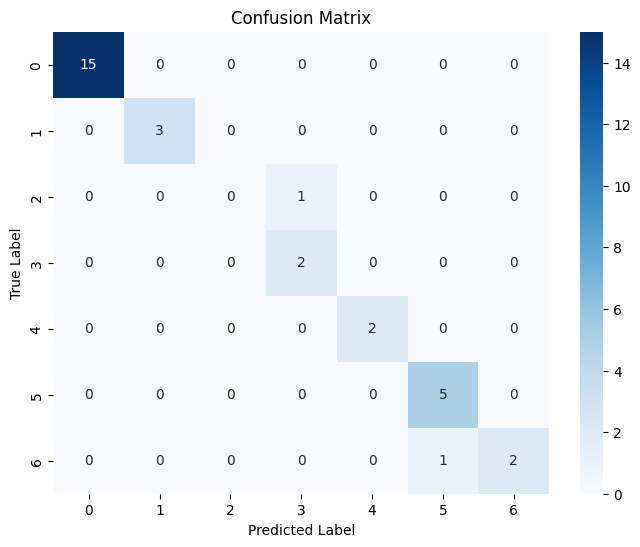

In [10]:

# ----------------------------------------
# 9. Confusion Matrix
# ----------------------------------------

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()